In [1]:

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
import pandas as pd

# Using engine='python' with quotechar and on_bad_lines to handle the unclosed quotes in this dataset
try:
    df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',
                     encoding='latin-1',
                     header=None,
                     engine='python',
                     quotechar='"',
                     on_bad_lines='skip')

    # Selecting target and text columns
    df = df[[0, 5]]
    df.columns = ['polarity', 'text']

    # Shuffle to get a mix of 0 (negative) and 4 (positive)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Dataset loaded successfully. Total rows: {len(df)}")
    print("Class distribution:")
    print(df['polarity'].value_counts())
except Exception as e:
    print(f"Loading failed: {e}")

Dataset loaded successfully. Total rows: 49235
Class distribution:
polarity
4    28112
0    21123
Name: count, dtype: int64


In [3]:
# Map polarity 0 to 0 (negative) and 4 to 1 (positive)
df['polarity'] = df['polarity'].map({0: 0, 4: 1})

# Drop any unexpected neutral values or errors if any
df.dropna(subset=['polarity'], inplace=True)
df['polarity'] = df['polarity'].astype(int)

print("Class distribution after mapping:")
print(df['polarity'].value_counts())

# Safety check
unique_classes = df['polarity'].nunique()
if unique_classes < 2:
    print(f"\nERROR: Only {unique_classes} class found. You need both 0 and 1 for classification.")
else:
    print(f"\nSuccess: Found {unique_classes} classes. Ready for training.")

Class distribution after mapping:
polarity
1    28112
0    21123
Name: count, dtype: int64

Success: Found 2 classes. Ready for training.


In [4]:
def clean_text(text):

    if not isinstance(text, str):
        return ''

    # lowercase
    text = text.lower()

    # handle contractions
    text = text.replace("n't", " not")

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove @mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtag symbol but keep word
    text = re.sub(r'#', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  http://twitpic.com/7je63 - Alice and me at the...   
1  hey @mafilsboss!!!!! let's get @Andrewgoldstei...   
2  @ashsimpsonwentz this confused me 4 a min... h...   
3  @julianmaestas: Awesome, thanks for being unde...   
4  @newbordeaux Bordeaux is moving to screwcaps? ...   

                                          clean_text  
0                                   alice jb concert  
1  hey let get wasted tomorrow would love everyon...  
2         confused min haha realized u talking bronx  
3                       awesome thanks understanding  
4              bordeaux moving screwcaps surely jest  


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['polarity'],
    test_size=0.2,
    random_state=42,
    stratify=df['polarity']
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 39388
Test size: 9847


In [6]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (39388, 8491)
TF-IDF shape (test): (9847, 8491)


In [7]:
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)

bnb_pred = bnb.predict(X_test_tfidf)

print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test, bnb_pred))
print("\nBernoulliNB Classification Report:\n", classification_report(y_test, bnb_pred))

Bernoulli Naive Bayes Accuracy: 0.7577942520564639

BernoulliNB Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.67      0.70      4225
           1       0.77      0.83      0.80      5622

    accuracy                           0.76      9847
   macro avg       0.75      0.75      0.75      9847
weighted avg       0.76      0.76      0.76      9847



In [8]:
print(df['polarity'].value_counts())

print(df['polarity'].unique())

print(y_train.value_counts())

polarity
1    28112
0    21123
Name: count, dtype: int64
[1 0]
polarity
1    22490
0    16898
Name: count, dtype: int64


In [9]:
print(df.shape)

(49235, 3)


In [10]:
print(df.shape)

(49235, 3)


In [11]:
svm = LinearSVC(max_iter=1000)
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:\n", classification_report(y_test, svm_pred))

SVM Accuracy: 0.746826444602417

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.66      0.69      4225
           1       0.76      0.81      0.79      5622

    accuracy                           0.75      9847
   macro avg       0.74      0.74      0.74      9847
weighted avg       0.75      0.75      0.75      9847



In [12]:
logreg = LogisticRegression(
    max_iter=1000,
    solver='liblinear'
)
logreg.fit(X_train_tfidf, y_train)

logreg_pred = logreg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 0.7593175586473038

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.65      0.70      4225
           1       0.76      0.84      0.80      5622

    accuracy                           0.76      9847
   macro avg       0.76      0.75      0.75      9847
weighted avg       0.76      0.76      0.76      9847



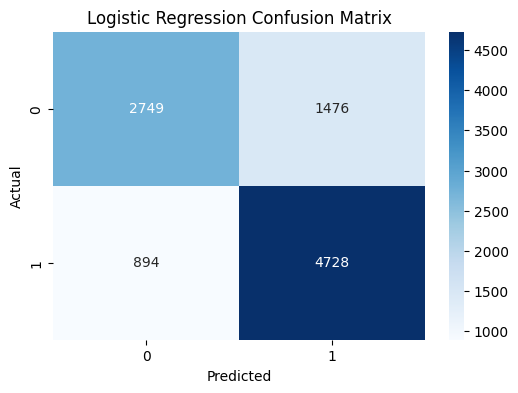

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, logreg_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [14]:
results = pd.DataFrame({
    'Model': ['BernoulliNB', 'SVM', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, bnb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, logreg_pred)
    ]
})

print(results.sort_values(
    by='Accuracy',
    ascending=False
))

                 Model  Accuracy
2  Logistic Regression  0.759318
0          BernoulliNB  0.757794
1                  SVM  0.746826


In [15]:
sample_tweets = ["I love this!", "I hate that!", "It was okay, not great."]
sample_vec = vectorizer.transform(sample_tweets)

print("\nSample Predictions:")
print("BernoulliNB:", bnb.predict(sample_vec))
print("SVM:", svm.predict(sample_vec))
print("Logistic Regression:", logreg.predict(sample_vec))


Sample Predictions:
BernoulliNB: [1 0 1]
SVM: [1 0 1]
Logistic Regression: [1 0 1]


In [16]:
import joblib

# Saving the Logistic Regression model and the TF-IDF vectorizer
joblib.dump(logreg, "sentiment_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

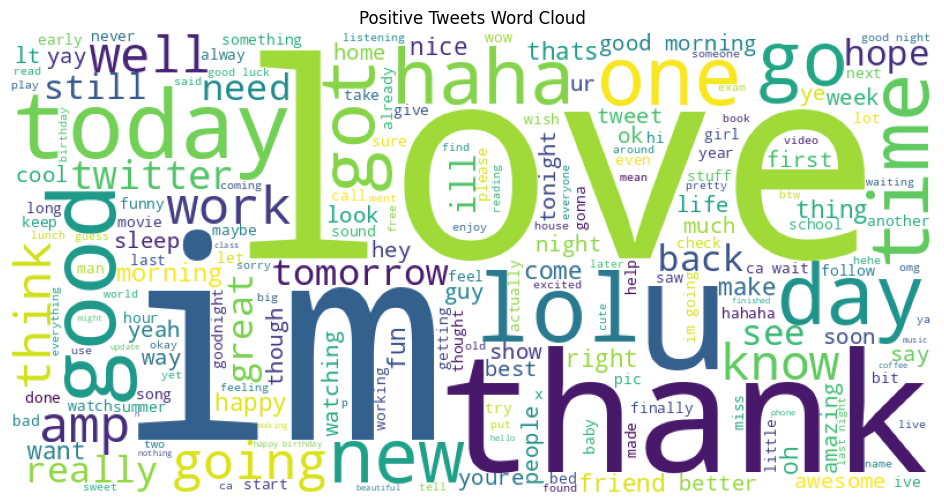

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter for positive sentiment (1)
pos_df = df[df.polarity == 1]

if len(pos_df) > 0:
    positive_text = ' '.join(pos_df['clean_text'].astype(str))

    if positive_text.strip():
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white'
        ).generate(positive_text)

        plt.figure(figsize=(12,6))
        plt.imshow(wordcloud)
        plt.axis("off")
        plt.title("Positive Tweets Word Cloud")
        plt.show()
    else:
        print("No words found in positive tweets to generate word cloud.")
else:
    print("No positive tweets found. Please re-run the data loading and mapping cells (ux0PLifQ9ZLs and WqgYUro5_fw3).")